<a href="https://colab.research.google.com/github/NEWTON1nonly/ML-projects/blob/main/Spam_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install transformers accelerate seaborn

Saving email.csv to email (1).csv
Dataset Shape: (5573, 2)
Columns: ['Category', 'Message']

Category Distribution:
Category
ham               4825
spam               747
{"mode":"full"       1
Name: count, dtype: int64

Label Mapping:
{'ham': 0, 'spam': 1}

Training Samples: 4457
Testing Samples: 1115

Using Device: cuda
GPU: Tesla T4


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Starting Training...

Epoch 1/3 | Training Loss: 0.0785
Epoch 2/3 | Training Loss: 0.0212
Epoch 3/3 | Training Loss: 0.0114

Training Completed Successfully!

DISTILBERT RESULTS
Accuracy: 99.28 %
Precision: 99.28 %
Recall: 99.28 %
F1 Score: 99.28 %

CLASSIFICATION REPORT

              precision    recall  f1-score   support

         ham       0.99      1.00      1.00       966
        spam       0.99      0.96      0.97       149

    accuracy                           0.99      1115
   macro avg       0.99      0.98      0.98      1115
weighted avg       0.99      0.99      0.99      1115



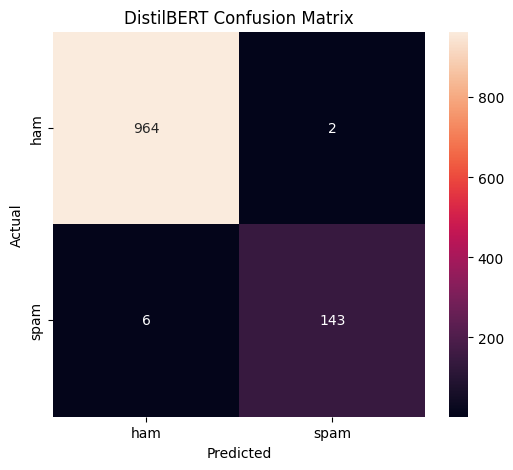

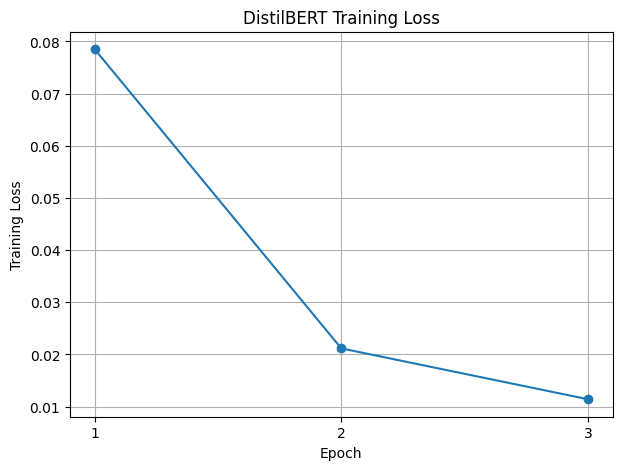


🎉 COMPLETE DISTILBERT PIPELINE FINISHED SUCCESSFULLY!


In [ ]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, DistilBertForSequenceClassification
from torch.optim import AdamW

uploaded = files.upload()

filename = list(uploaded.keys())[0]

try:
    df = pd.read_csv(filename, encoding="utf-8")
except:
    df = pd.read_csv(filename, encoding="latin-1")

df.columns = df.columns.astype(str).str.strip()

print("Dataset Shape:", df.shape)
print("Columns:", df.columns.tolist())

message_col = None
category_col = None

for col in df.columns:
    if col.lower() in ["message", "text", "sms", "content"]:
        message_col = col
    if col.lower() in ["category", "label", "class", "target"]:
        category_col = col

if message_col is None or category_col is None:
    print(df.head())
    raise ValueError("Message or Category column could not be detected.")

df = df[[category_col, message_col]].copy()

df.columns = ["Category", "Message"]

df.dropna(inplace=True)

df["Message"] = df["Message"].astype(str)

df["Category"] = df["Category"].astype(str).str.strip().str.lower()

print("\nCategory Distribution:")
print(df["Category"].value_counts())

label_map = {}

unique_labels = sorted(df["Category"].unique())

if "ham" in unique_labels and "spam" in unique_labels:
    label_map = {"ham": 0, "spam": 1}
else:
    for i, label in enumerate(unique_labels):
        label_map[label] = i

# Filter out rows where Category is not in label_map keys to prevent NaN in Label column
# This line was already present but the kernel state shows it wasn't fully effective.
# df = df[df['Category'].isin(label_map.keys())].copy()

df["Label"] = df["Category"].map(label_map)

# Explicitly drop rows where 'Label' is NaN after mapping to handle unmapped categories
# and ensure the target variable is clean for train_test_split.
initial_rows = len(df)
df.dropna(subset=['Label'], inplace=True)
if len(df) < initial_rows:
    print(f"Dropped {initial_rows - len(df)} rows due to unmapped categories resulting in NaN labels.")

# Convert 'Label' column to integer type now that NaNs are handled.
df['Label'] = df['Label'].astype(int)

print("\nLabel Mapping:")
print(label_map)

X = df["Message"]
y = df["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining Samples:", len(X_train))
print("Testing Samples:", len(X_test))

X_train_bert = X_train.tolist()
X_test_bert = X_test.tolist()

y_train_bert = y_train.tolist()
y_test_bert = y_test.tolist()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("\nUsing Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

train_encodings = tokenizer(
    X_train_bert,
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    X_test_bert,
    truncation=True,
    padding=True,
    max_length=128
)

class SpamDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(value[idx])
            for key, value in self.encodings.items()
        }
        item["labels"] = torch.tensor(
            self.labels[idx],
            dtype=torch.long
        )
        return item

train_dataset = SpamDataset(
    train_encodings,
    y_train_bert
)

test_dataset = SpamDataset(
    test_encodings,
    y_test_bert
)

batch_size = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("\nTraining Batches:", len(train_loader))
print("Testing Batches:", len(test_loader))

model = DistilBertForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(label_map)
)

model.to(device)

optimizer = AdamW(
    model.parameters(),
    lr=2e-5
)

epochs = 3

train_losses = []

print("\nStarting Training...\n")

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for batch in train_loader:

        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss

        total_loss += loss.item()

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

    average_loss = total_loss / len(train_loader)

    train_losses.append(average_loss)

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Training Loss: {average_loss:.4f}"
    )

print("\nTraining Completed Successfully!")

model.eval()

predictions = []
true_labels = []

with torch.no_grad():

    for batch in test_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits

        preds = torch.argmax(
            logits,
            dim=1
        )

        predictions.extend(
            preds.cpu().numpy()
        )

        true_labels.extend(
            labels.cpu().numpy()
        )

accuracy = accuracy_score(
    true_labels,
    predictions
)

precision = precision_score(
    true_labels,
    predictions,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    true_labels,
    predictions,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    true_labels,
    predictions,
    average="weighted",
    zero_division=0
)

print("\nDISTILBERT RESULTS")
print("=" * 40)
print("Accuracy:", round(accuracy * 100, 2), "%")
print("Precision:", round(precision * 100, 2), "%")
print("Recall:", round(recall * 100, 2), "%")
print("F1 Score:", round(f1 * 100, 2), "%")

reverse_label_map = {
    value: key
    for key, value in label_map.items()
}

target_names = [
    reverse_label_map[i]
    for i in sorted(reverse_label_map.keys())
]

print("\nCLASSIFICATION REPORT\n")

print(
    classification_report(
        true_labels,
        predictions,
        target_names=target_names,
        zero_division=0
    )
)

cm = confusion_matrix(
    true_labels,
    predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=target_names,
    yticklabels=target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("DistilBERT Confusion Matrix")

plt.show()

plt.figure(figsize=(7, 5))

plt.plot(
    range(1, epochs + 1),
    train_losses,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("DistilBERT Training Loss")

plt.xticks(range(1, epochs + 1))

plt.grid()

plt.show()

print("\n🎉 COMPLETE DISTILBERT PIPELINE FINISHED SUCCESSFULLY!")

## Test with Custom Input

In [4]:
def predict_message(message):
    model.eval()
    inputs = tokenizer(
        message,
        truncation=True,
        padding=True,
        max_length=128,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        prediction = torch.argmax(logits, dim=1).item()

    return reverse_label_map[prediction]

# Example usage:
# message_to_predict = "Congratulations! You've won a free iPhone! Click here:"
# predicted_label = predict_message(message_to_predict)
# print(f"The message is predicted as: {predicted_label}")

### Custom Message Testing

In [ ]:
# Using the message_input from the kernel state
predicted_label_kernel = predict_message(message_input)
print(f"Message from kernel state: '{message_input}'")
print(f"Predicted as: {predicted_label_kernel}\n")

In [ ]:
# Example 1: Spam message
message_to_predict_spam = "Congratulations! You've won a free iPhone! Click here: http://bit.ly/123xyz"
predicted_label_spam = predict_message(message_to_predict_spam)
print(f"Message: '{message_to_predict_spam}'")
print(f"Predicted as: {predicted_label_spam}\n")

In [ ]:
# Example 2: Ham message
message_to_predict_ham = "Hey, let's catch up tomorrow for coffee."
predicted_label_ham = predict_message(message_to_predict_ham)
print(f"Message: '{message_to_predict_ham}'")
print(f"Predicted as: {predicted_label_ham}")